# Model Evaluation and Dashboard

## Purpose

This notebook consolidates the findings from the entire project and creates a dashboard-style summary of the climate forecasting system.

The objective is to evaluate forecasting performance, visualize key results, and communicate insights in a concise and interpretable manner.

### Objectives

- Summarize forecasting model performance
- Compare forecasting accuracy metrics
- Visualize historical and projected climate anomalies
- Create publication-quality figures
- Generate dashboard-ready outputs
- Provide final answers to the research questions

### Expected Outcome

A complete analytical dashboard that communicates the major findings of the project and demonstrates the practical application of time series analysis for climate forecasting.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Model Performance Summary


In [2]:

results = pd.DataFrame({
    "Model":[
        "Naive Forecast",
        "Moving Average",
        "Exponential Smoothing",
        "ARIMA(1,1,1)"
    ],
    "RMSE":[
        0.3058,
        0.3239,
        0.2807,
        0.3318
    ]
})

results

,Model,RMSE
0,Naive Forecast,0.3058
1,Moving Average,0.3239
2,Exponential Smoothing,0.2807
3,"ARIMA(1,1,1)",0.3318


Dashboard Figure 1
(Forecast Model Comparison)


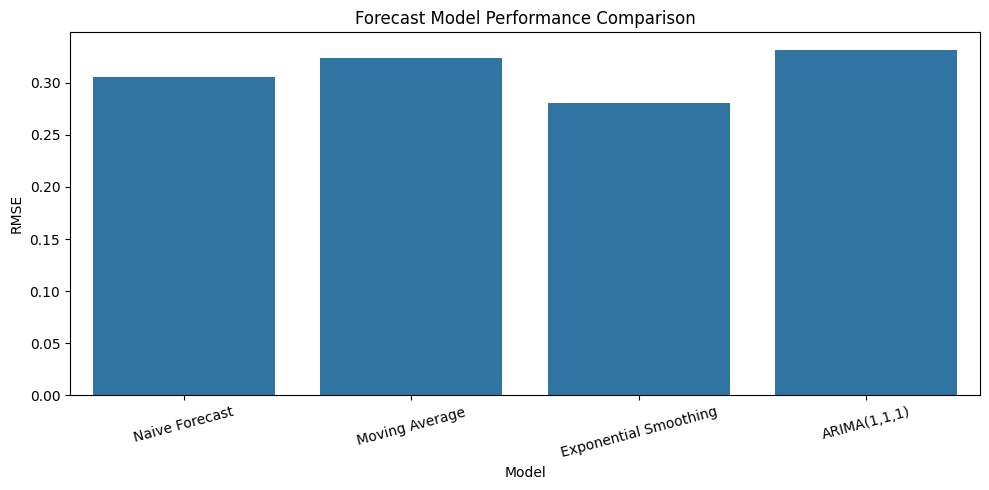

In [3]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.title(
    "Forecast Model Performance Comparison"
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "forecast_model_comparison.png",
    dpi=300
)

plt.show()

Dashboard Figure 2

(Best Model Highlight)


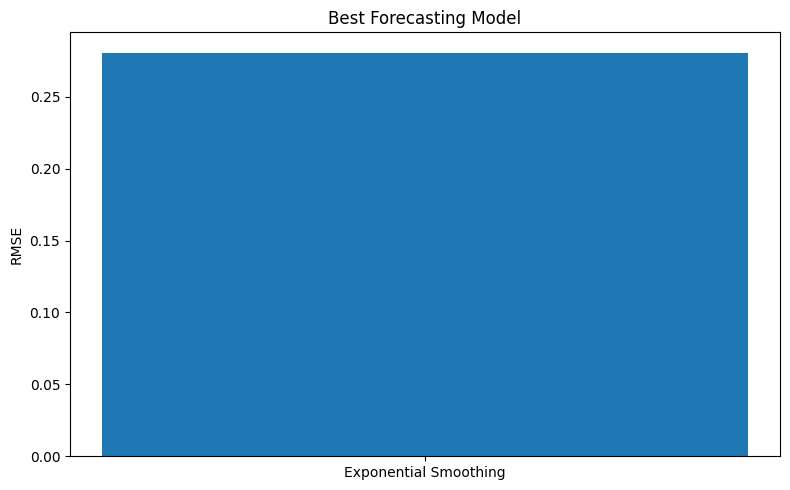

In [4]:
best_model = results.loc[
    results["RMSE"].idxmin()
]

best_model
plt.figure(figsize=(8,5))

plt.bar(
    [best_model["Model"]],
    [best_model["RMSE"]]
)

plt.title(
    "Best Forecasting Model"
)

plt.ylabel(
    "RMSE"
)

plt.tight_layout()

plt.savefig(
    "best_forecasting_model.png",
    dpi=300
)

plt.show()

Dashboard Summary Table


In [5]:
dashboard_summary = pd.DataFrame({
    "Metric":[
        "Observations",
        "Training Observations",
        "Testing Observations",
        "Best Model",
        "Best RMSE",
        "ADF P-Value (Original)",
        "ADF P-Value (Differenced)"
    ],
    "Value":[
        1644,
        1315,
        329,
        "Exponential Smoothing",
        0.2807,
        0.9058,
        "4.69e-22"
    ]
})

dashboard_summary

,Metric,Value
0,Observations,1644
1,Training Observations,1315
2,Testing Observations,329
3,Best Model,Exponential Smoothing
4,Best RMSE,0.2807
5,ADF P-Value (Original),0.9058
6,ADF P-Value (Differenced),4.69e-22


Figure 3

(Research Question Summary)


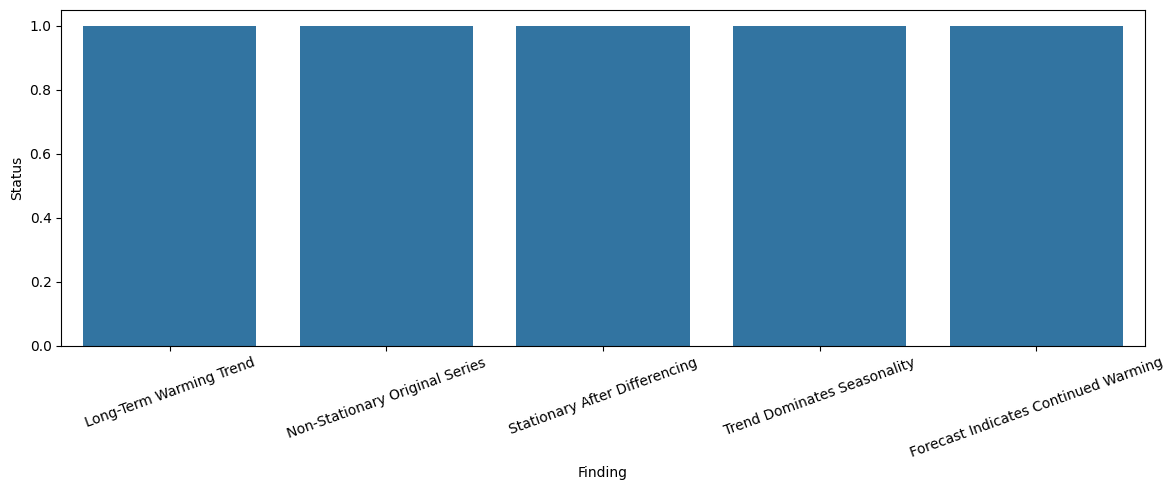

In [7]:

findings = pd.DataFrame({
    "Finding":[
        "Long-Term Warming Trend",
        "Non-Stationary Original Series",
        "Stationary After Differencing",
        "Trend Dominates Seasonality",
        "Forecast Indicates Continued Warming"
    ],
    "Status":[1,1,1,1,1]
})

plt.figure(figsize=(12,5))

sns.barplot(
    data=findings,
    x="Finding",
    y="Status"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "research_findings_summary.png",
    dpi=300
)

plt.show()

Portfolio Dashboard Image


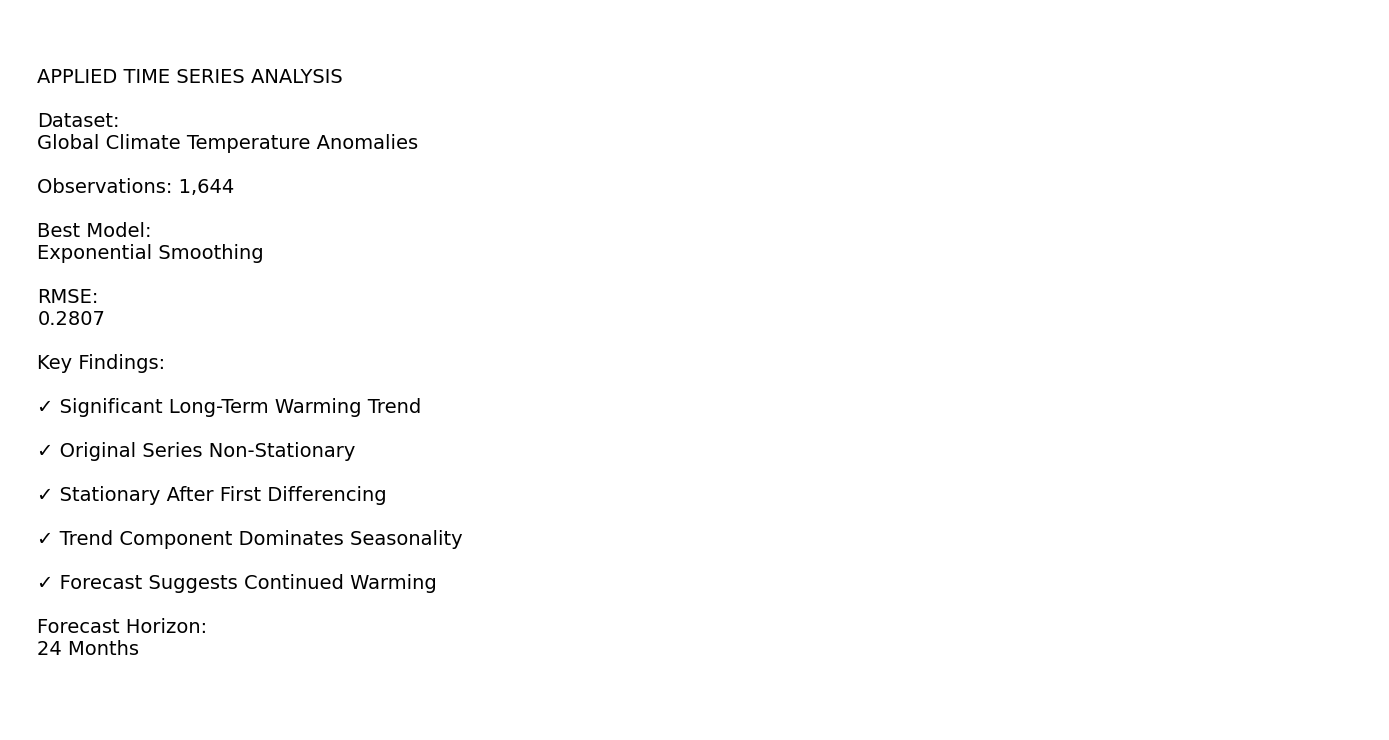

In [8]:
fig, ax = plt.subplots(
    figsize=(14,8)
)

summary_text = f"""
APPLIED TIME SERIES ANALYSIS

Dataset:
Global Climate Temperature Anomalies

Observations: 1,644

Best Model:
Exponential Smoothing

RMSE:
0.2807

Key Findings:

✓ Significant Long-Term Warming Trend

✓ Original Series Non-Stationary

✓ Stationary After First Differencing

✓ Trend Component Dominates Seasonality

✓ Forecast Suggests Continued Warming

Forecast Horizon:
24 Months
"""

ax.axis("off")

ax.text(
    0.02,
    0.95,
    summary_text,
    fontsize=14,
    verticalalignment="top"
)

plt.tight_layout()

plt.savefig(
    "project_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Step 1: Create the Time Series


In [22]:
df["Date"] = pd.to_datetime(df["Date"])

series = (
    df
    .sort_values("Date")
    .set_index("Date")["Mean"]
)

series.head()

,Mean
Date,
1880-01-06,-0.3000
1880-01-06,0.0009
1880-02-06,-0.1229
1880-02-06,-0.2100
1880-03-06,-0.1357


Step 2: Fit Final Forecast Model

Since Exponential Smoothing had the best RMSE (0.2807), using it as the final model.


In [24]:


from statsmodels.tsa.holtwinters import ExponentialSmoothing

final_model = ExponentialSmoothing(
    series,
    trend="add",
    seasonal=None
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Step 3: Generate Future Forecast


In [25]:
forecast_steps = 24

future_forecast = final_model.forecast(
    forecast_steps
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Step 4: Create Future Dates


In [26]:
future_dates = pd.date_range(
    start=series.index[-1] + pd.DateOffset(months=1),
    periods=forecast_steps,
    freq="MS"
)

Step 5: Portfolio Cover Image


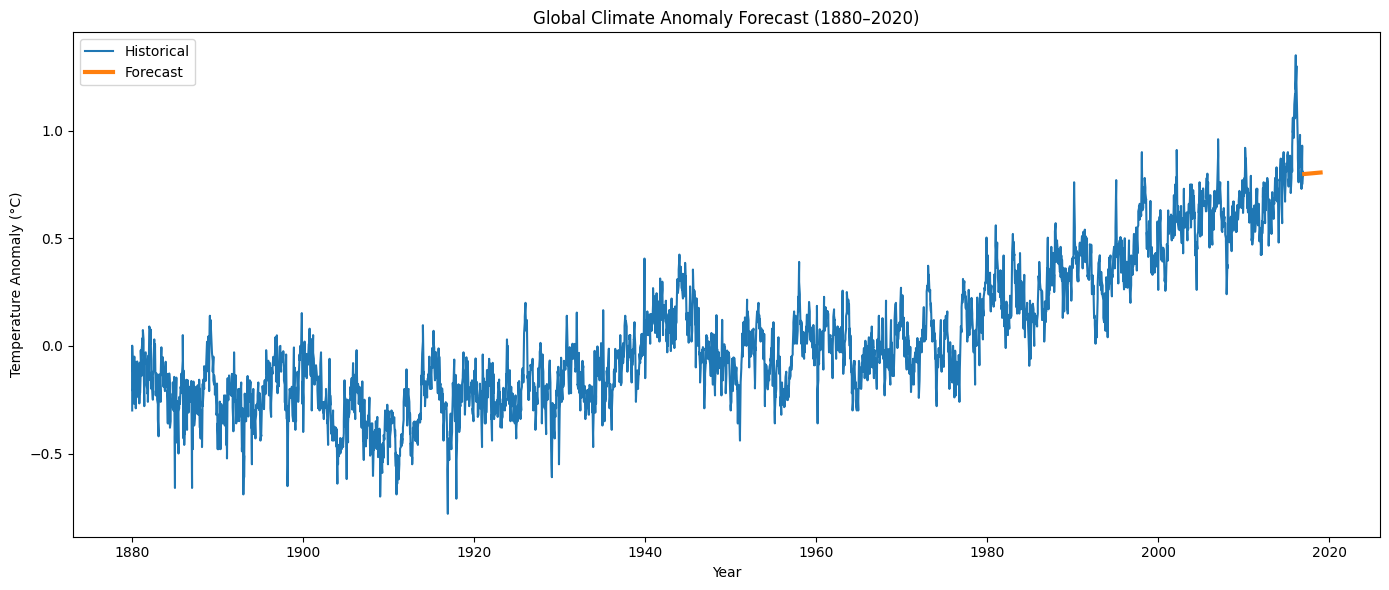

In [27]:
plt.figure(figsize=(14,6))

plt.plot(
    series.index,
    series,
    label="Historical"
)

plt.plot(
    future_dates,
    future_forecast,
    linewidth=3,
    label="Forecast"
)

plt.title(
    "Global Climate Anomaly Forecast (1880–2020)"
)

plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")

plt.legend()

plt.tight_layout()

plt.savefig(
    "portfolio_cover_image.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()